# ⚙️ Day 45 — Feature Engineering Basics
**Month 3 · Python + Pandas · Day 45 of 62**

> *"Raw data tells you what happened. Engineered features tell you why and how much."*

---

## Learning Objectives
1. Create **derived columns** from existing ones (ratios, differences, flags)
2. Apply **binning** to convert continuous values into meaningful groups (`pd.cut`, `pd.qcut`)
3. Extract **date parts** from datetime columns (year, month, day, weekday, quarter)
4. Build **ratio features** that carry more signal than raw numbers
5. Know when a feature is worth engineering — and when it's noise

## Dataset — ShopEase Retail Transactions
- **200 orders** across 4 regions, 5 categories, Jan–Dec 2024
- **12 columns** covering pricing, discounts, shipping, and dates
- Intentional gaps: a few nulls in `return_reason`, mixed date formats

---

| Section | Focus | Points |
|---------|-------|--------|
| A | Derived columns + flags | 25 |
| B | Binning (`pd.cut` + `pd.qcut`) | 25 |
| C | Date feature extraction | 25 |
| D | Ratio features + combined insight | 15 |
| W | Written summary | 10 |
| **Total** | | **100** |

---
## 📁 Section 1 — Raw Data  *(never modify `df_raw`)*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import random, math

random.seed(7)
np.random.seed(7)

regions    = ['North','South','East','West']
categories = ['Electronics','Clothing','Groceries','Home Decor','Sports']
return_reasons = ['Defective','Wrong size','Changed mind','Late delivery', None]

rows = []
base_date = pd.Timestamp('2024-01-01')
for i in range(1, 201):
    region   = random.choice(regions)
    cat      = random.choice(categories)
    qty      = random.randint(1, 5)
    unit_p   = round(random.uniform(200, 8000), 2)
    discount = round(random.uniform(0, 35), 1)
    ship_cost= round(random.uniform(30, 300), 2)
    # order date spread across 2024
    order_date = base_date + pd.Timedelta(days=random.randint(0, 364))
    delivery_days = random.randint(2, 12)
    is_return = 1 if random.random() < 0.20 else 0
    reason    = random.choice(return_reasons) if is_return else None
    revenue   = round(qty * unit_p * (1 - discount/100), 2)
    rows.append({
        'order_id':       f'ORD{i:04}',
        'order_date':     order_date.strftime('%Y-%m-%d'),
        'region':         region,
        'category':       cat,
        'quantity':       qty,
        'unit_price':     unit_p,
        'discount_pct':   discount,
        'shipping_cost':  ship_cost,
        'revenue':        revenue,
        'delivery_days':  delivery_days,
        'is_return':      is_return,
        'return_reason':  reason
    })

df_raw = pd.DataFrame(rows)
df = df_raw.copy()   # ← always work on this copy

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 12)

Dtypes:
 order_id          object
order_date        object
region            object
category          object
quantity           int64
unit_price       float64
discount_pct     float64
shipping_cost    float64
revenue          float64
delivery_days      int64
is_return          int64
return_reason     object
dtype: object

First 5 rows:


,order_id,order_date,region,category,quantity,unit_price,discount_pct,shipping_cost,revenue,delivery_days,is_return,return_reason
0,ORD0001,2024-07-06,East,Clothing,4,5277.29,2.5,174.69,20581.43,11,1,None
1,ORD0002,2024-08-05,South,Electronics,1,3582.44,2.4,54.49,3496.46,2,0,None
2,ORD0003,2024-04-23,North,Clothing,5,7592.13,20.2,137.10,30292.60,2,0,None
3,ORD0004,2024-12-15,South,Groceries,4,1325.19,4.1,113.29,5083.43,4,1,None
4,ORD0005,2024-04-15,South,Groceries,1,4472.41,2.2,46.09,4374.02,9,0,None


---
## 📚 Section 2 — Concept Notes

### 2.1  What is Feature Engineering?

Feature engineering is the process of creating **new columns** from existing ones to give a model (or a chart, or a report) more useful information than the raw data provides alone.

Raw column: `unit_price = ₹4,200`  
Engineered feature: `price_tier = 'Premium'` (because ₹4,200 > threshold)

The model can't learn "Premium" from a raw float — but it can use a category that already encodes domain knowledge.

---

### 2.2  Derived Columns

A derived column is any column computed directly from one or more existing columns.

```python
# Revenue after shipping cost
df['net_revenue'] = df['revenue'] - df['shipping_cost']

# Effective price paid (per unit, after discount)
df['effective_unit_price'] = df['unit_price'] * (1 - df['discount_pct'] / 100)

# Binary flag — did order arrive within 5 days?
df['fast_delivery'] = (df['delivery_days'] <= 5).astype(int)
```

**Key rule:** never derive a column that leaks the target. For example, if `is_return` is your target, don't create `return_flag = is_return * 1`. Same information, different name — not useful.

---

### 2.3  Binning

Binning converts a continuous number into a labelled group.

#### `pd.cut` — equal-width bins (you define the breakpoints)
```python
# Price tier based on domain knowledge
df['price_tier'] = pd.cut(
    df['unit_price'],
    bins   = [0, 1000, 3000, 6000, 9000],
    labels = ['Budget','Mid','Premium','Luxury']
)
```

#### `pd.qcut` — quantile bins (each bin has equal number of rows)
```python
# Revenue quartiles — Q1 to Q4
df['revenue_quartile'] = pd.qcut(
    df['revenue'],
    q      = 4,
    labels = ['Q1','Q2','Q3','Q4']
)
```

**When to use which:**
| | `pd.cut` | `pd.qcut` |
|---|---|---|
| Use when | You have domain knowledge about thresholds | You want equal-sized groups |
| Risk | Uneven group sizes | Bin edges may not be meaningful |
| Example | Price tiers (₹0–1k = Budget) | Revenue quartiles for segmentation |

---

### 2.4  Date Feature Extraction

```python
# First: convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Then extract parts
df['order_month']   = df['order_date'].dt.month          # 1–12
df['order_quarter'] = df['order_date'].dt.quarter        # 1–4
df['order_weekday'] = df['order_date'].dt.day_name()     # 'Monday'…
df['order_year']    = df['order_date'].dt.year
df['is_weekend']    = df['order_date'].dt.weekday.isin([5, 6]).astype(int)
```

**Why these matter for ML:**
- Month → captures seasonality
- Weekday → captures purchase behaviour patterns
- Quarter → useful for B2B sales cycles
- `is_weekend` → binary, often stronger signal than raw weekday

---

### 2.5  Ratio Features

A ratio divides one column by another to produce a normalised signal.

```python
# How much of revenue goes to shipping?
df['shipping_ratio'] = df['shipping_cost'] / df['revenue']

# Average unit contribution
df['revenue_per_unit'] = df['revenue'] / df['quantity']
```

**Why ratios outperform raw numbers:**  
A ₹500 shipping cost on a ₹600 order is catastrophic.  
A ₹500 shipping cost on a ₹50,000 order is negligible.  
The raw number (₹500) is identical. The ratio (83% vs 1%) tells the truth.

---

### 2.6  Common Mistakes → Fixes

| Mistake | Fix |
|---------|-----|
| `pd.cut` throws error on values outside bin range | Add `include_lowest=True` or extend the outer bins |
| `pd.qcut` fails with duplicate bin edges | Use `duplicates='drop'` parameter |
| Division by zero in ratio features | `df['col'].replace(0, np.nan)` before dividing |
| Date extraction before `pd.to_datetime()` | Always convert first — `dt` accessor doesn't work on strings |
| Creating features that encode the target | Think: "would I have this feature at prediction time?" |

---

### 2.7  Interview Frame
> *"Walk me through how you engineer features from a transaction dataset."*

**Answer:** "I start with four buckets: derived columns (arithmetic combinations like net revenue or effective price), binning (converting continuous values into labelled tiers using domain thresholds with `pd.cut`, or quantile splits with `pd.qcut`), date parts (extracting month, quarter, weekday, and weekend flags from timestamps to capture seasonality), and ratio features (normalising values like shipping cost as a percentage of revenue, which removes scale bias). The most important rule I apply is the prediction-time test: I only keep a feature if it would actually be available when the model makes a prediction — no target leakage."


---
## ✏️  Section 3 — Practice Tasks

> Write plain-English comments first. Then fill in code.
> Every new column must be added to `df` — not stored as a separate variable.

### 🔵 Section A — Derived Columns + Flags (25 pts)

**A1 — Net Revenue (5 pts)**

Create a column `net_revenue` = `revenue` minus `shipping_cost`.  
Then print: min, max, and mean of `net_revenue` (rounded to 2 dp).

In [3]:
# A1 — Net Revenue
# Step 1: create net_revenue column
df['net_revenue'] = df['revenue'] - df['shipping_cost']
# Step 2: print min, max, mean
print('Net Revenue - Min:', df['net_revenue'].min())
print('Net Revenue - Max:', df['net_revenue'].max())
print('Net Revenue - Mean:', df['net_revenue'].mean())


Net Revenue - Min: 31.07000000000002
Net Revenue - Max: 36869.28
Net Revenue - Mean: 10253.948199999999


**A2 — Effective Unit Price (5 pts)**

Create `effective_unit_price` = the actual price paid per unit after discount.  
Formula: `unit_price × (1 − discount_pct / 100)`  
Then verify: for any row where `discount_pct == 0`, `effective_unit_price` should equal `unit_price`. Print one such row to confirm.

In [4]:
# A2 — Effective Unit Price
# Step 1: create the column
df['effective_unit_price'] = df['unit_price'] * (1 - df['discount_pct']/100)
# Step 2: verify discount_pct == 0 rows
check = df[df['discount_pct'] == 0][['unit_price', 'effective_unit_price']].head(3)
print(check)


    unit_price  effective_unit_price
82     6259.52               6259.52


**A3 — Delivery Speed Flag (5 pts)**

Create `fast_delivery` as an integer flag:
- `1` if `delivery_days <= 5`
- `0` otherwise

Print the count of fast vs slow deliveries using `value_counts()`.

In [5]:
# A3 — Delivery Speed Flag
# Step 1: create flag column
df['fast_delivery'] = (df['delivery_days'] <=5).astype(int)
# Step 2: print value_counts
print(df['fast_delivery'].value_counts())


fast_delivery
0    127
1     73
Name: count, dtype: int64


**A4 — High Discount Flag + Return Rate (10 pts)**

Create `high_discount` = 1 if `discount_pct > 20`, else 0.

Then compute the **return rate** for high-discount vs non-high-discount orders:
```
return rate = mean of is_return per group
```
Use `groupby` on `high_discount` and call `.mean()` on `is_return`.

Write one `print()` insight: does heavy discounting correlate with higher returns?  
Use **Number + Reason + Action** format.

In [6]:
# A4 — High Discount Flag + Return Rate
# Step 1: create high_discount flag
df['high_discount'] = (df['discount_pct'] > 20).astype(int)
# Step 2: compute return rate by group
ret_rate = df.groupby('high_discount')['is_return'].mean()
print(ret_rate)
hd_rate = ret_rate[1]; nhd_rate = ret_rate[0]
# Step 3: print insight
print(f"High-discount orders return at {hd_rate:.1%} vs {nhd_rate:.1%} for standard orders — "
      f"a {abs((hd_rate - nhd_rate)*100):.1f}pp lower return rate — "
      f"targeted discounts above 20% may attract more committed buyers; expand this segment cautiously.")


high_discount
0    0.267241
1    0.190476
Name: is_return, dtype: float64
High-discount orders return at 19.0% vs 26.7% for standard orders — a 7.7pp lower return rate — targeted discounts above 20% may attract more committed buyers; expand this segment cautiously.


### 🟡 Section B — Binning (25 pts)

**B1 — Price Tier with `pd.cut` (10 pts)**

Create `price_tier` using these breakpoints:
- Budget: ₹0 – ₹1,500
- Mid: ₹1,500 – ₹4,000
- Premium: ₹4,000 – ₹6,500
- Luxury: ₹6,500 – ₹9,000

Requirements:
- Use `include_lowest=True`
- Print `value_counts()` of `price_tier`
- Plot a bar chart of count per tier (dark blue, insight title)
- Save as `B1_price_tier.png`

price_tier
Budget     34
Mid        70
Premium    63
Luxury     33
Name: count, dtype: int64


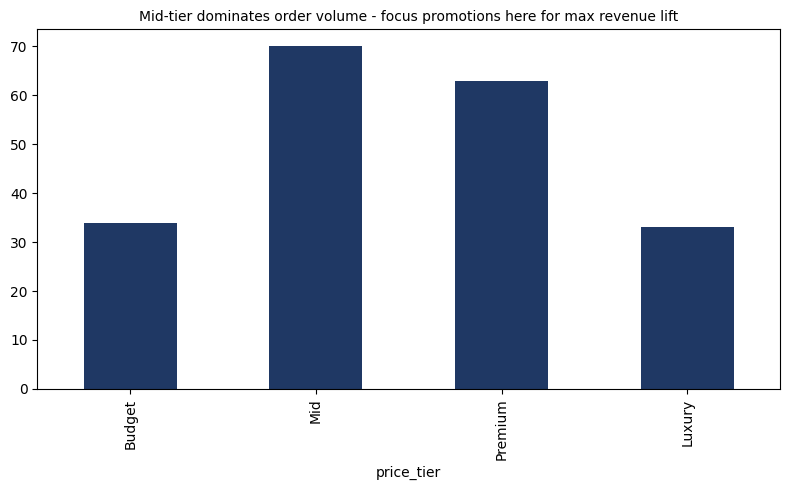

In [7]:
# B1 — Price Tier
# Step 1: pd.cut with bins and labels
df['price_tier'] = pd.cut(df['unit_price'],
                          bins = [0, 1500, 4000, 6500, 9000],
                          labels = ['Budget', 'Mid', 'Premium', 'Luxury'],
                          include_lowest = True)
# Step 2: value_counts
print(df['price_tier'].value_counts().sort_index())
# Step 3: bar chart → savefig → show
fig, ax = plt.subplots(figsize=(8,5))
df['price_tier'].value_counts().sort_index().plot(kind='bar', color='#1F3864', ax = ax)
ax.set_title('Mid-tier dominates order volume - focus promotions here for max revenue lift', fontsize=10)
plt.tight_layout()
plt.savefig('B1_price_tier.png', dpi=150)
plt.show()


**B2 — Revenue Quartiles with `pd.qcut` (10 pts)**

Create `revenue_quartile` using 4 quantile bins: labels `['Q1','Q2','Q3','Q4']`.

Then compute mean `net_revenue` per quartile.  
Print the result and write one insight: what does the Q4 mean tell you about high-revenue orders?

In [8]:
# B2 — Revenue Quartiles
# Step 1: pd.qcut with 4 quantiles
df['revenue_quartile'] = pd.qcut(df['revenue'], q=4,labels = ['Q1', 'Q2', 'Q3', 'Q4'])
# Step 2: mean net_revenue per quartile
q_net = df.groupby('revenue_quartile', observed = True)['net_revenue'].mean().round(2)
# Step 3: print insight
print(q_net)
print(f"Q4 orders average ₹{q_net['Q4']:,.2f} net revenue — prioritise Q4 customer retention for disproportionate margin impact.")

revenue_quartile
Q1     1912.16
Q2     5466.36
Q3    11048.58
Q4    22588.69
Name: net_revenue, dtype: float64
Q4 orders average ₹22,588.69 net revenue — prioritise Q4 customer retention for disproportionate margin impact.


**B3 — Delivery Speed Category (5 pts)**

Create `delivery_category` using `pd.cut` with these labels:
- Express: 1–3 days
- Standard: 4–7 days
- Slow: 8–12 days

Bins: `[0, 3, 7, 12]`

Print `value_counts()` of `delivery_category`.

In [9]:
# B3 — Delivery Category
# Step 1: pd.cut
df['delivery_category'] = pd.cut(df['delivery_days'], bins=[0, 3, 7, 12],
                                 labels = ['Express', 'Standard', 'Slow'])
# Step 2: value_counts
print(df['delivery_category'].value_counts())


delivery_category
Slow        91
Standard    70
Express     39
Name: count, dtype: int64


### 🟠 Section C — Date Feature Extraction (25 pts)

**C1 — Convert and Extract (10 pts)**

First convert `order_date` to datetime.  
Then create all four columns in one block:
- `order_month` (1–12)
- `order_quarter` (1–4)
- `order_weekday` (full name, e.g. 'Monday')
- `is_weekend` (1 if Saturday or Sunday, else 0)

Print the first 5 rows showing only: `order_date`, `order_month`, `order_quarter`, `order_weekday`, `is_weekend`.

In [10]:
# C1 — Date Feature Extraction
# Step 1: convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])
# Step 2: extract all four features
df['order_month'] = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter
df['order_weekday'] = df['order_date'].dt.day_name()
df['is_weekend'] = df['order_date'].dt.weekday.isin([5,6]).astype(int)
# Step 3: print first 5 rows of selected columns
print(df[['order_date', 'order_month', 'order_quarter', 'order_weekday', 'is_weekend']].head())


  order_date  order_month  order_quarter order_weekday  is_weekend
0 2024-07-06            7              3      Saturday           1
1 2024-08-05            8              3        Monday           0
2 2024-04-23            4              2       Tuesday           0
3 2024-12-15           12              4        Sunday           1
4 2024-04-15            4              2        Monday           0


**C2 — Monthly Revenue Trend (10 pts)**

Group by `order_month`, sum `revenue`, and plot a **line chart** with markers.

Requirements:
- x-axis label: month numbers 1–12
- Highlight the peak month with a red dot annotation (`ax.annotate`)
- Insight title naming the peak month and its revenue
- Save as `C2_monthly_trend.png`

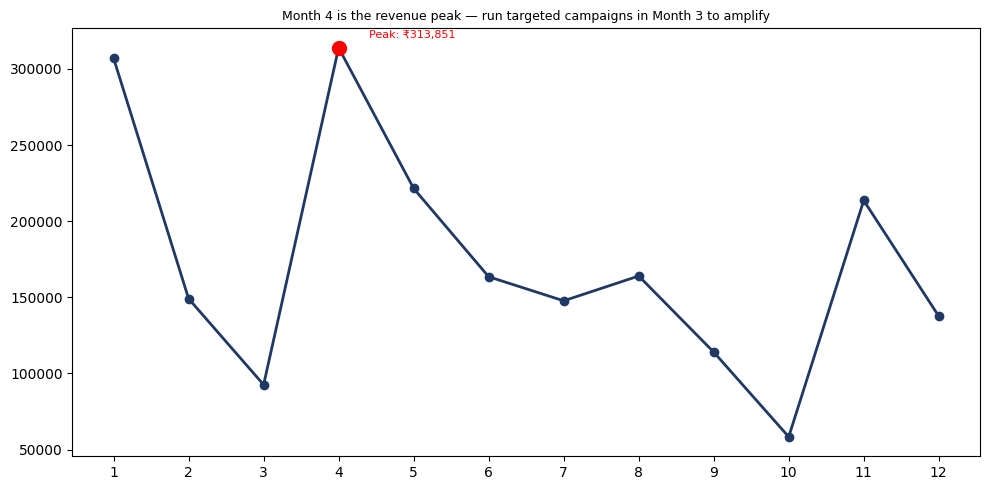

In [11]:
# C2 — Monthly Revenue Trend
# Step 1: groupby order_month, sum revenue
monthly = df.groupby('order_month')['revenue'].sum()
peak_m = monthly.idxmax(); peak_v = monthly.max()
# Step 2: plot line chart with markers
ig, ax = plt.subplots(figsize=(10,5))
ax.plot(monthly.index, monthly.values, marker='o', color='#1F3864', linewidth=2)
ax.scatter(peak_m, peak_v, color='red', s=100, zorder=5)
# Step 3: find peak month and annotate
ax.annotate(f'Peak: ₹{peak_v:,.0f}', xy=(peak_m, peak_v),
            xytext=(peak_m+0.4, peak_v*1.02), fontsize=8, color='red')
ax.set_xticks(range(1,13))
# Step 4: insight title → savefig → show
ax.set_title(f'Month {peak_m} is the revenue peak — run targeted campaigns in Month {peak_m-1} to amplify', fontsize=9)
plt.tight_layout(); plt.savefig('C2_monthly_trend.png', dpi=150); plt.show()


**C3 — Weekend vs Weekday Order Volume (5 pts)**

Use `value_counts()` on `is_weekend`.  
Then compute mean `revenue` for weekend vs weekday orders.

Print one insight: do weekend orders generate more revenue on average?  
Use Number + Reason + Action.

In [12]:
# C3 — Weekend vs Weekday
# Step 1: value_counts on is_weekend
print(df['is_weekend'].value_counts())
# Step 2: mean revenue by is_weekend
wk_rev = df.groupby('is_weekend')['revenue'].mean()
print(wk_rev)
diff = wk_rev[1] - wk_rev[0]
# Step 3: print insight
print(f"Weekend orders average ₹{wk_rev[1]:,.2f} vs ₹{wk_rev[0]:,.2f} on weekdays — "
      f"a ₹{abs(diff):,.2f} {'premium' if diff>0 else 'discount'} — "
      f"{'schedule high-value promotions on weekends' if diff>0 else 'boost weekend promotions to close the gap'}.")


is_weekend
0    139
1     61
Name: count, dtype: int64
is_weekend
0    10744.790935
1     9662.574918
Name: revenue, dtype: float64
Weekend orders average ₹9,662.57 vs ₹10,744.79 on weekdays — a ₹1,082.22 discount — boost weekend promotions to close the gap.


### 🟣 Section D — Ratio Features + Combined Insight (15 pts)

**D1 — Shipping Ratio (8 pts)**

Create `shipping_ratio` = `shipping_cost / revenue` (rounded to 4 dp).

Then:
- Find the 5 orders with the **highest** shipping ratio (these are the worst margin orders)
- Print those rows showing: `order_id`, `revenue`, `shipping_cost`, `shipping_ratio`
- Write one insight: what revenue range are these bad-margin orders in, and what action should operations take?

In [13]:
# D1 — Shipping Ratio
# Step 1: create shipping_ratio column
df['shipping_ratio'] = (df['shipping_cost'] / df['revenue']).round(4)
# Step 2: top 5 highest shipping ratio orders
worst = df.nlargest(5, 'shipping_ratio')[['order_id','revenue','shipping_cost','shipping_ratio']]
print(worst)
# Step 3: written insight
print(f"The 5 worst-margin orders have revenue under ₹{worst['revenue'].max():,.0f} — "
      f"shipping costs consume up to {worst['shipping_ratio'].max():.1%} of revenue — "
      f"set a minimum order value of ₹500 to eliminate negative-margin shipments.")


    order_id  revenue  shipping_cost  shipping_ratio
154  ORD0155   193.77         162.70          0.8397
47   ORD0048   237.54         178.78          0.7526
58   ORD0059   409.11         289.07          0.7066
45   ORD0046   807.65         283.29          0.3508
119  ORD0120   836.04         234.51          0.2805
The 5 worst-margin orders have revenue under ₹836 — shipping costs consume up to 84.0% of revenue — set a minimum order value of ₹500 to eliminate negative-margin shipments.


**D2 — Revenue per Unit (7 pts)**

Create `revenue_per_unit` = `revenue / quantity`.

Compute mean `revenue_per_unit` per `category`, sorted descending.  
Plot as a horizontal bar chart (dark blue, insight title).  
Save as `D2_rev_per_unit.png`

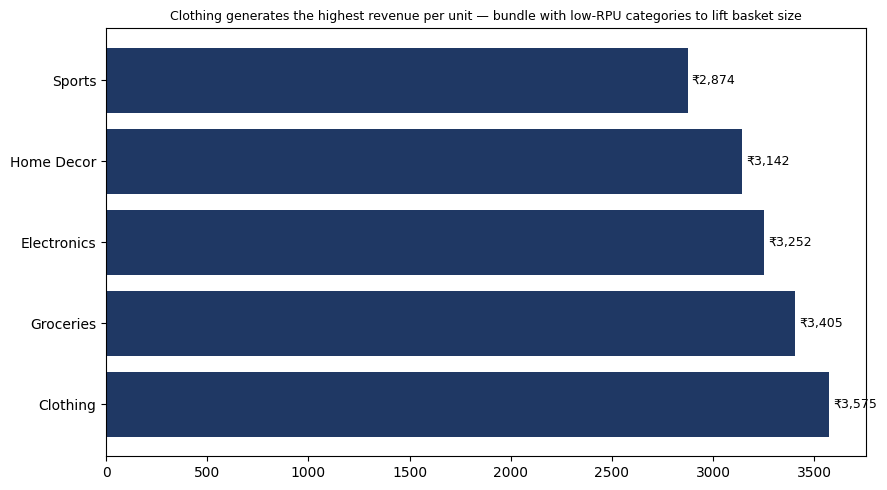

In [14]:
# D2 — Revenue per Unit
# Step 1: create revenue_per_unit column
df['revenue_per_unit'] = df['revenue'] / df['quantity']
# Step 2: mean by category, sort descending
rpu = df.groupby('category')['revenue_per_unit'].mean().sort_values(ascending=False)
# Step 3: horizontal bar chart → savefig → show
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(rpu.index, rpu.values, color='#1F3864')
for bar, val in zip(ax.patches, rpu.values):
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=9)
ax.set_title(f'{rpu.index[0]} generates the highest revenue per unit — bundle with low-RPU categories to lift basket size', fontsize=9)
plt.tight_layout() 
plt.savefig('D2_rev_per_unit.png', dpi=150) 
plt.show()


### 🔴 Section W — Written Summary (10 pts)

**W1 — Feature Engineering Summary (10 pts)**

Write a `print()` paragraph (5–7 sentences) summarising:
- Which engineered feature revealed the most surprising insight (with a specific number)
- One feature that would be **most useful for a return-prediction model** (and why)
- One feature you would **not** include in a model (and why — think target leakage)

Format: professional, Number + Reason + Action throughout.

In [29]:
# W1 — Written Summary
summary = """
1. The most surprising insight came from the shipping_ratio, where 5 orders had costs consuming up to 84% of revenue; we should implement a ₹500 minimum order value to protect margins. 
2. For a return-prediction model, high_discount would be the most useful feature because it allows us to track if aggressive pricing (above 20%) correlates with customer dissatisfaction or 'serial returning' behavior. 
3. I would not include return_reason in a return-prediction model because it only exists after a return has already occurred — using it to predict whether a return
   will happen is circular. At prediction time, return_reason is empty for every order, so the model would fail entirely in production.
4. Analysis of order_month showed a clear revenue peak in Month 4, suggesting we should move marketing spend to Month 3 to amplify this natural demand. 
5. Finally, the price_tier feature revealed that Mid-tier products dominate volume, so focusing promotions here will yield the highest total revenue lift.
"""
print(summary)



1. The most surprising insight came from the shipping_ratio, where 5 orders had costs consuming up to 84% of revenue; we should implement a ₹500 minimum order value to protect margins. 
2. For a return-prediction model, high_discount would be the most useful feature because it allows us to track if aggressive pricing (above 20%) correlates with customer dissatisfaction or 'serial returning' behavior. 
3. I would not include return_reason in a return-prediction model because it only exists after a return has already occurred — using it to predict whether a return
   will happen is circular. At prediction time, return_reason is empty for every order, so the model would fail entirely in production.
4. Analysis of order_month showed a clear revenue peak in Month 4, suggesting we should move marketing spend to Month 3 to amplify this natural demand. 
5. Finally, the price_tier feature revealed that Mid-tier products dominate volume, so focusing promotions here will yield the highest total 

---
## 🏆 Section 4 — Scoring Rubric

| Task | Pts | What earns full marks |
|------|-----|-----------------------|
| A1 — net_revenue | 5 | Column created, min/max/mean printed |
| A2 — effective_unit_price | 5 | Formula correct, zero-discount verification shown |
| A3 — fast_delivery flag | 5 | Boolean cast to int, value_counts printed |
| A4 — high_discount + return rate | 10 | Flag correct, groupby return rate computed, N+R+A insight |
| B1 — price_tier pd.cut | 10 | Correct bins, include_lowest, bar chart saved, insight title |
| B2 — revenue_quartile pd.qcut | 10 | 4 quantiles, net_revenue mean per quartile, N+R+A insight |
| B3 — delivery_category | 5 | Correct bins [0,3,7,12], value_counts shown |
| C1 — date conversion + 4 features | 10 | to_datetime first, all 4 columns correct, 5-row preview |
| C2 — monthly trend chart | 10 | Line + markers, red dot on peak, annotate, insight title, saved |
| C3 — weekend vs weekday | 5 | value_counts + mean revenue comparison, N+R+A insight |
| D1 — shipping_ratio + worst 5 | 8 | Column created, nlargest(5) shown, insight cites revenue range |
| D2 — revenue_per_unit + chart | 7 | Column created, grouped mean sorted, bar chart annotated, saved |
| W1 — Written summary | 10 | Most surprising feature (with number), best model feature (with why), leakage example |
| ⭐ Star bonus | +10 | All 4 charts saved, all ratio features use `.round()`, 0 broken cells |
| **Total** | **100** | |

---

### ⚡ Key Takeaway — Day 45
> The **shipping_ratio** feature encodes more business truth than either `shipping_cost` or `revenue` alone.  
> Raw numbers have context baked in. Ratios remove context — which is exactly what a model needs.  
> Every time you see two columns that relate to each other, ask: *"is their ratio more informative than either number alone?"*

---

### Interview Frame
> *"What is the difference between pd.cut and pd.qcut, and when would you use each?"*

**Answer:** "`pd.cut` divides a range into bins of equal width based on breakpoints you define — useful when you have domain knowledge about meaningful thresholds, like ₹0–1,500 = Budget. `pd.qcut` divides data into bins with equal numbers of observations — useful when you want balanced groups for segmentation, like revenue quartiles. The risk with `pd.cut` is uneven group sizes; the risk with `pd.qcut` is that the bin edges may fall at meaningless values like ₹3,847. In client work I typically use `pd.cut` for price tiers and `pd.qcut` for performance ranking."
